In [77]:
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
df = pd.read_csv('ratings_Electronics.csv',header = None)

In [7]:
df.columns = ['user_id', 'product_id', 'ratings', 'timestamp']

In [8]:
df.head()

,user_id,product_id,ratings,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


In [9]:
#Dropping Timestamp
df = df.drop(['timestamp'],axis=1)

In [10]:
df.head()

,user_id,product_id,ratings
0,AKM1MP6P0OYPR,0132793040,5.0
1,A2CX7LUOHB2NDG,0321732944,5.0
2,A2NWSAGRHCP8N5,0439886341,1.0
3,A2WNBOD3WNDNKT,0439886341,3.0
4,A1GI0U4ZRJA8WN,0439886341,1.0


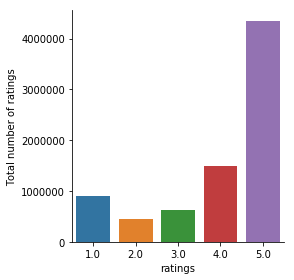

In [78]:
g = sns.factorplot("ratings", data=df, kind='count')
g.set_ylabels("Total number of ratings") 

In [30]:
#Checking how many products got different ratings
df.groupby('ratings').agg({'product_id': 'count'}).reset_index()

,ratings,product_id
0,1.0,901765
1,2.0,456322
2,3.0,633073
3,4.0,1485781
4,5.0,4347541


In [33]:
#Checking each product got how many ratings
df.groupby('product_id').agg({'ratings': 'count'}).sort_values('ratings',ascending=False).head(10)

,ratings
product_id,
B0074BW614,18244
B00DR0PDNE,16454
B007WTAJTO,14172
B0019EHU8G,12285
B006GWO5WK,12226
B003ELYQGG,11617
B003ES5ZUU,10276
B007R5YDYA,9907
B00622AG6S,9823


In [34]:
#Since the heighest rating is 5, separating the products with rating 5 and checking the products which got most number of 5
#ratings
df4 = df[df['ratings'] == 5]

In [35]:
df4.shape

(4347541, 3)

In [36]:
df4.groupby(by='product_id').count().sort_values(by='ratings',ascending=False).head(10)

,user_id,ratings
product_id,,
B0074BW614,12765,12765
B007WTAJTO,10674,10674
B0019EHU8G,10637,10637
B003ES5ZUU,8480,8480
B00DR0PDNE,8281,8281
B006GWO5WK,8111,8111
B007R5YDYA,7862,7862
B003ELYQGG,7754,7754
B000LRMS66,7324,7324


In [85]:
#Selecting users who have provided 50 or more ratings

In [15]:
df1 = df['user_id'].value_counts()

In [37]:
df2 = df1[df1>50].index.tolist()

In [38]:
df3 = df[df['user_id'].isin(df2)]

In [39]:
df3 = df3.drop_duplicates()

In [86]:
#Popularity based model
#Importing Recommenders and Evaluation files

In [40]:
import Recommenders as Recommenders
import Evaluation as Evaluation

In [41]:
users = df3['user_id'].unique()
len(users)

1466

In [42]:
items = df3['product_id'].unique()
len(items)

47155

In [43]:
train_data, test_data = train_test_split(df3, test_size = 0.20, random_state=0)

In [48]:
pop_model =  Recommenders.popularity_recommender_py()

In [49]:
pop_model.create(train_data, 'user_id', 'product_id')

In [50]:
pop_model.recommend(users[5])

,user_id,product_id,score,Rank
32948,A25RTRAPQAJBDJ,B0088CJT4U,169,1.0
20944,A25RTRAPQAJBDJ,B003ES5ZUU,148,2.0
9278,A25RTRAPQAJBDJ,B000N99BBC,127,3.0
32319,A25RTRAPQAJBDJ,B007WTAJTO,118,4.0
32626,A25RTRAPQAJBDJ,B00829TIEK,116,5.0
32622,A25RTRAPQAJBDJ,B00829THK0,108,6.0
33233,A25RTRAPQAJBDJ,B008DWCRQW,108,7.0
18544,A25RTRAPQAJBDJ,B002R5AM7C,101,8.0
24270,A25RTRAPQAJBDJ,B004CLYEDC,90,9.0
32663,A25RTRAPQAJBDJ,B00834SJNA,84,10.0


In [51]:
pr.recommend(users[25])

,user_id,product_id,score,Rank
32948,ABVYGB2TKBO8F,B0088CJT4U,169,1.0
20944,ABVYGB2TKBO8F,B003ES5ZUU,148,2.0
9278,ABVYGB2TKBO8F,B000N99BBC,127,3.0
32319,ABVYGB2TKBO8F,B007WTAJTO,118,4.0
32626,ABVYGB2TKBO8F,B00829TIEK,116,5.0
32622,ABVYGB2TKBO8F,B00829THK0,108,6.0
33233,ABVYGB2TKBO8F,B008DWCRQW,108,7.0
18544,ABVYGB2TKBO8F,B002R5AM7C,101,8.0
24270,ABVYGB2TKBO8F,B004CLYEDC,90,9.0
32663,ABVYGB2TKBO8F,B00834SJNA,84,10.0


In [87]:
#We can observe that for all users popularity model provides the same reult. 

In [88]:
#Item Similarity model - this is present in Recommenders file

In [52]:
sim_model = Recommenders.item_similarity_recommender_py()

In [53]:
sim_model.create(train_data, 'user_id', 'product_id')

In [54]:
sim_model.get_user_items(users[5])

['B00017O6Q6',
 'B000TJFEYO',
 'B0006DPPW4',
 'B0002EXJRA',
 'B0001ZYAN2',
 'B000FJ2TVY',
 'B00009ZOIZ',
 'B007W66RCU',
 'B00BCA41PW',
 'B00JC5Y6YA',
 'B000BMHERE',
 'B0036CGZEE',
 'B000BYVIQU',
 'B005NCNDOU',
 'B000JLU2A8',
 'B00FXPL1XM',
 'B004CLYEDC',
 'B0009IG3U4',
 'B003YNO0LA',
 'B003PL0AME',
 'B000PAS9IU',
 'B00A2T6X0K',
 'B00871SR68',
 'B00DUTIZJG',
 '0972683275',
 'B008MF48J4',
 'B0096J0WRW',
 'B008R6WUZC',
 'B00BF9I0JI',
 'B000BPNUCY',
 'B0002KRCHW',
 'B00902SFC4',
 'B00009W3IB',
 'B00009UH9J',
 'B009APC0R2',
 'B005DKZTNK',
 'B0002CNTU4',
 'B000782SLO',
 'B009QV744O',
 'B00JY4QCJQ',
 'B000EHHOOE',
 'B005TDWVQY',
 'B000PH7X30',
 'B0034CL2ZI',
 'B004CZ9U96']

In [55]:
sim_model.recommend(users[5])

No. of unique songs for the user: 45
no. of unique songs in the training set: 40778
Non zero values in cooccurence_matrix :27985


,user_id,song,score,rank
0,A25RTRAPQAJBDJ,B00CAN88VI,0.014582,1
1,A25RTRAPQAJBDJ,B004CLYEE6,0.013700,2
2,A25RTRAPQAJBDJ,B00G5RDU5O,0.013308,3
3,A25RTRAPQAJBDJ,B0088CJT4U,0.013067,4
4,A25RTRAPQAJBDJ,B005I6EU48,0.013025,5
5,A25RTRAPQAJBDJ,B005QCDY50,0.011793,6
6,A25RTRAPQAJBDJ,B008X9ZBVI,0.011694,7
7,A25RTRAPQAJBDJ,B002TLTE6Y,0.011627,8
8,A25RTRAPQAJBDJ,B007W7PIZ6,0.011625,9
9,A25RTRAPQAJBDJ,B0079UAT0A,0.011583,10


In [89]:
#Collaberative model using Surprise

In [57]:
from surprise import KNNWithMeans
from surprise import Dataset, Reader
from surprise import accuracy
from surprise.model_selection import train_test_split

In [58]:
reader = Reader(rating_scale=(1, 5))

In [59]:
data = Dataset.load_from_df(df3, reader)

In [60]:
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=.2,random_state=0)

In [65]:
trainset.ur

defaultdict(list,
            {0: [(0, 5.0),
              (3806, 5.0),
              (6133, 5.0),
              (8494, 1.0),
              (8808, 5.0),
              (10921, 5.0),
              (11135, 5.0),
              (11159, 1.0),
              (13009, 5.0),
              (14172, 4.0),
              (134, 5.0),
              (10045, 5.0),
              (7810, 1.0),
              (13243, 5.0),
              (4889, 5.0),
              (15454, 5.0),
              (3178, 5.0),
              (17061, 5.0),
              (18563, 1.0),
              (19653, 5.0),
              (19836, 5.0),
              (4885, 5.0),
              (621, 4.0),
              (15089, 5.0),
              (5582, 5.0),
              (21499, 5.0),
              (23801, 5.0),
              (24901, 5.0),
              (14186, 5.0),
              (6679, 4.0),
              (28657, 5.0),
              (1082, 4.0),
              (14639, 5.0),
              (31207, 4.0),
              (31686, 5.0),
              (340

In [61]:
algo = KNNWithMeans(k=50, sim_options={'name': 'pearson_baseline', 'user_based': True})
algo.fit(trainset)

Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.


In [67]:
uid = str(196)  # raw user id
iid = str(302)  # raw item id

In [68]:
pred = algo.predict(uid, iid, r_ui=4, verbose=True)

user: 196        item: 302        r_ui = 4.00   est = 4.26   {'was_impossible': True, 'reason': 'User and/or item is unkown.'}


In [69]:
test_pred = algo.test(testset)
accuracy.rmse(test_pred)

RMSE: 1.0569


1.0568568465834014

In [70]:
test_pred[10]

Prediction(uid='AJEOFP6ZWY0MK', iid='B0042RA8C2', r_ui=5.0, est=4.226415094339623, details={'actual_k': 0, 'was_impossible': False})

In [71]:
df_pred = pd.DataFrame(test_pred, columns=['uid', 'iid', 'rui', 'est', 'details'])

In [73]:
df_pred.head()

,uid,iid,rui,est,details
0,A1143YEAZYMYHJ,B006I5MKZY,2.0,4.093303,"{'actual_k': 8, 'was_impossible': False}"
1,A28N2AWOVO2PB,B008D97LNE,5.0,4.447818,"{'actual_k': 5, 'was_impossible': False}"
2,A20951I210L0IB,B007POCWD2,4.0,4.263015,"{'was_impossible': True, 'reason': 'User and/o..."
3,A37IRE9GZ0CZ7I,B006AR2SKW,3.0,4.188406,"{'actual_k': 0, 'was_impossible': False}"
4,A10Y058K7B96C6,B008X9Z9ZQ,4.0,4.818483,"{'actual_k': 9, 'was_impossible': False}"


In [74]:
testset_new = trainset.build_anti_testset()
len(testset_new)
testset_new[0:5]
predictions = algo.test(testset_new[0:10000])
predictions_df = pd.DataFrame([[x.uid,x.est] for x in predictions])
predictions_df.columns = ["userId","est_rating"]
predictions_df.sort_values(by = ["userId", "est_rating"],ascending=False,inplace=True)
predictions_df.head()
top_10_recos = predictions_df.groupby("userId").head(10).reset_index(drop=True)

In [75]:
top_10_recos

,userId,est_rating
0,A18A5VSD0IPN14,5.0
1,A18A5VSD0IPN14,5.0
2,A18A5VSD0IPN14,5.0
3,A18A5VSD0IPN14,5.0
4,A18A5VSD0IPN14,5.0
5,A18A5VSD0IPN14,5.0
6,A18A5VSD0IPN14,5.0
7,A18A5VSD0IPN14,5.0
8,A18A5VSD0IPN14,5.0
9,A18A5VSD0IPN14,5.0


In [84]:
test = df_pred.copy()
test.drop({"details"}, inplace=True, axis=1)
test.columns = ['user_id', 'product_id', 'actual', 'model_predictions']
test.head()

,user_id,product_id,actual,model_predictions
0,A1143YEAZYMYHJ,B006I5MKZY,2.0,4.093303
1,A28N2AWOVO2PB,B008D97LNE,5.0,4.447818
2,A20951I210L0IB,B007POCWD2,4.0,4.263015
3,A37IRE9GZ0CZ7I,B006AR2SKW,3.0,4.188406
4,A10Y058K7B96C6,B008X9Z9ZQ,4.0,4.818483


In [90]:
#Getting top 5 product 

In [79]:
predictions_df = pd.DataFrame([[x.uid,x.iid,x.est] for x in predictions])

In [80]:
predictions_df.columns = ["user_id","product_id","est_rating"]
predictions_df.sort_values(by = ["user_id","product_id", "est_rating"],ascending=False,inplace=True)

In [81]:
top_5_recos = predictions_df.groupby("user_id").head(5).reset_index(drop=True)
top_5_recos.head(5)

,user_id,product_id,est_rating
0,A18A5VSD0IPN14,B00LKG1MC8,4.425532
1,A18A5VSD0IPN14,B00LGQ6HL8,4.425532
2,A18A5VSD0IPN14,B00L3YHF6O,4.425532
3,A18A5VSD0IPN14,B00L2442H0,4.425532
4,A18A5VSD0IPN14,B00L21HC7A,4.425532


In [ ]:
# The Popularity based model has recommended the same set of products to all users and can be used when recommendation is not
# user specific. 
# Similarity based model recommendations depending upon product similarity
# Model-based Collaborative Filtering has more coverage and it is a personalised recommender system